In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

## #1 ##

In [11]:
df = pd.read_csv("TitanicDataset.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis, MO  


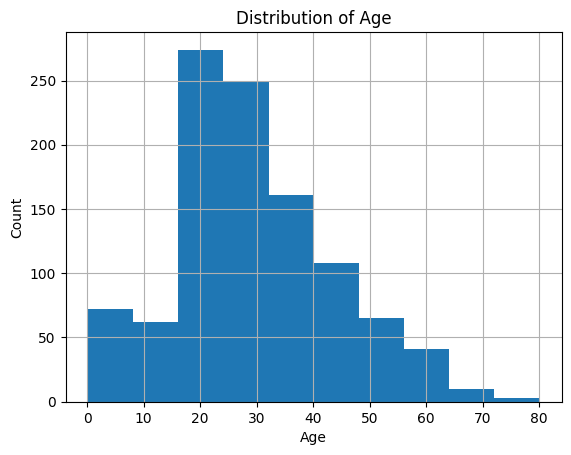

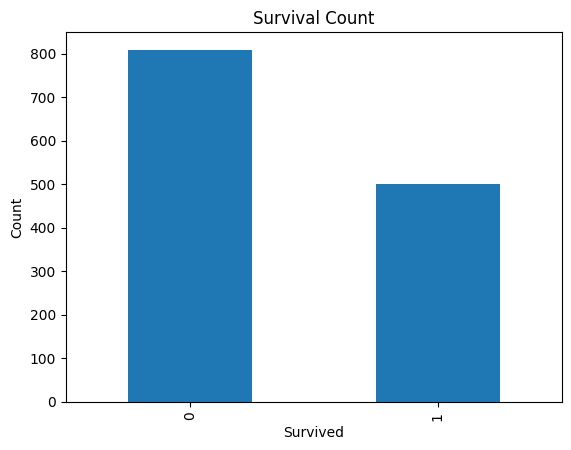

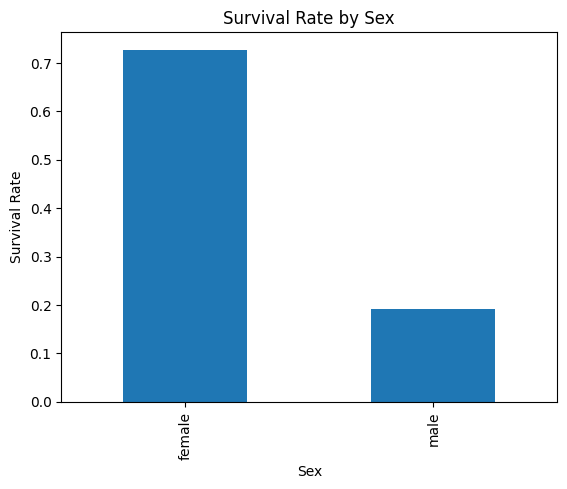

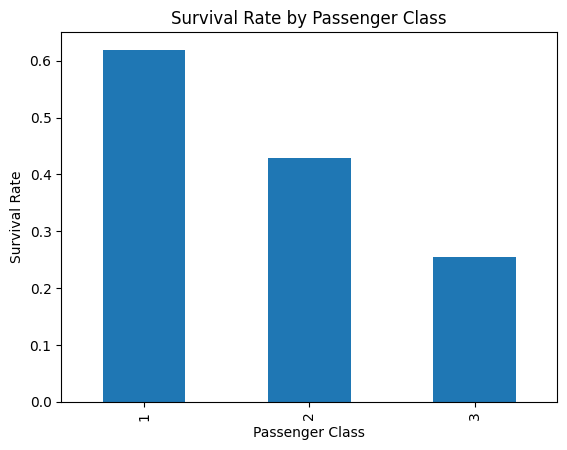

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("TitanicDataset.csv")


plt.figure()
df["age"].hist()
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure()
df["survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

plt.figure()
df.groupby("sex")["survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

plt.figure()
df.groupby("pclass")["survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

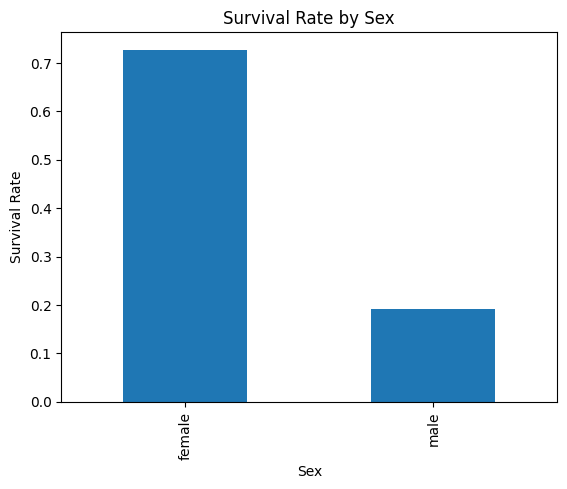

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("TitanicDataset.csv")

df.groupby("sex")["survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

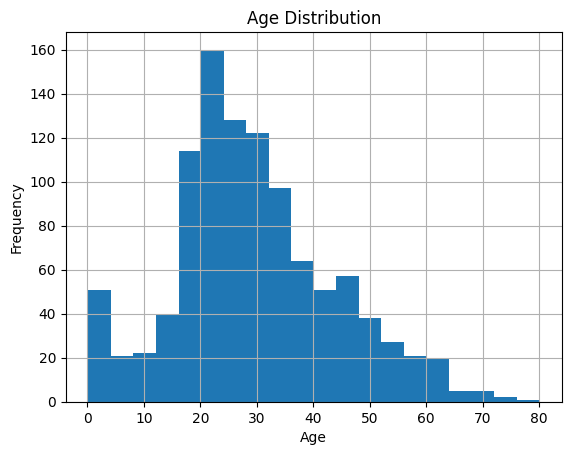

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("TitanicDataset.csv")

df["age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

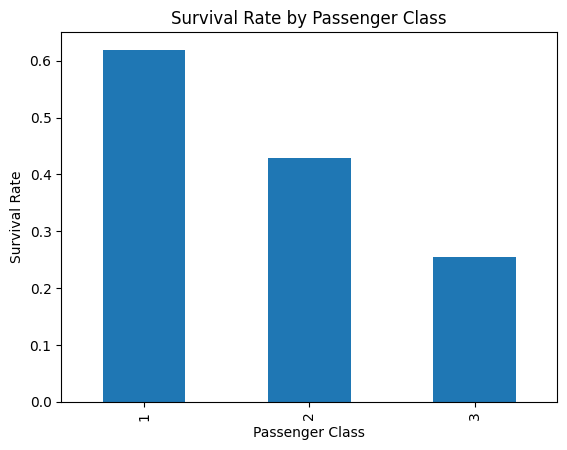

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("TitanicDataset.csv")

df.groupby("pclass")["survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

I handled missing values in the age column by replacing them with the median age. This is useful as the median is less affected by extreme outliers than the mean. I converted sex into a numerical format by changing male to 0 and female to 1, so the DecisionTree can understand the column.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("TitanicDataset.csv")
from sklearn.model_selection import train_test_split

X = df[["pclass", "age", "sibsp", "parch", "fare"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1047, 5)
X_test shape: (262, 5)
y_train shape: (1047,)
y_test shape: (262,)


Using random_state is important because it makes the split reproducible. The train and test data would change every time the code runs without it which could change the accuracy results. Setting random_state=42 makes the results consistent and easier to compare.

## #3 ##

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

train_preds = tree_model.predict(X_train)
test_preds = tree_model.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9455587392550143
Test Accuracy: 0.6755725190839694


If the training accuracy is 100% but the test accuracy is around 70%, the model is overfitting. This means the tree memorized the training data too closely, including small details, so it does not perform as well on new unseen data.

## #4 ##

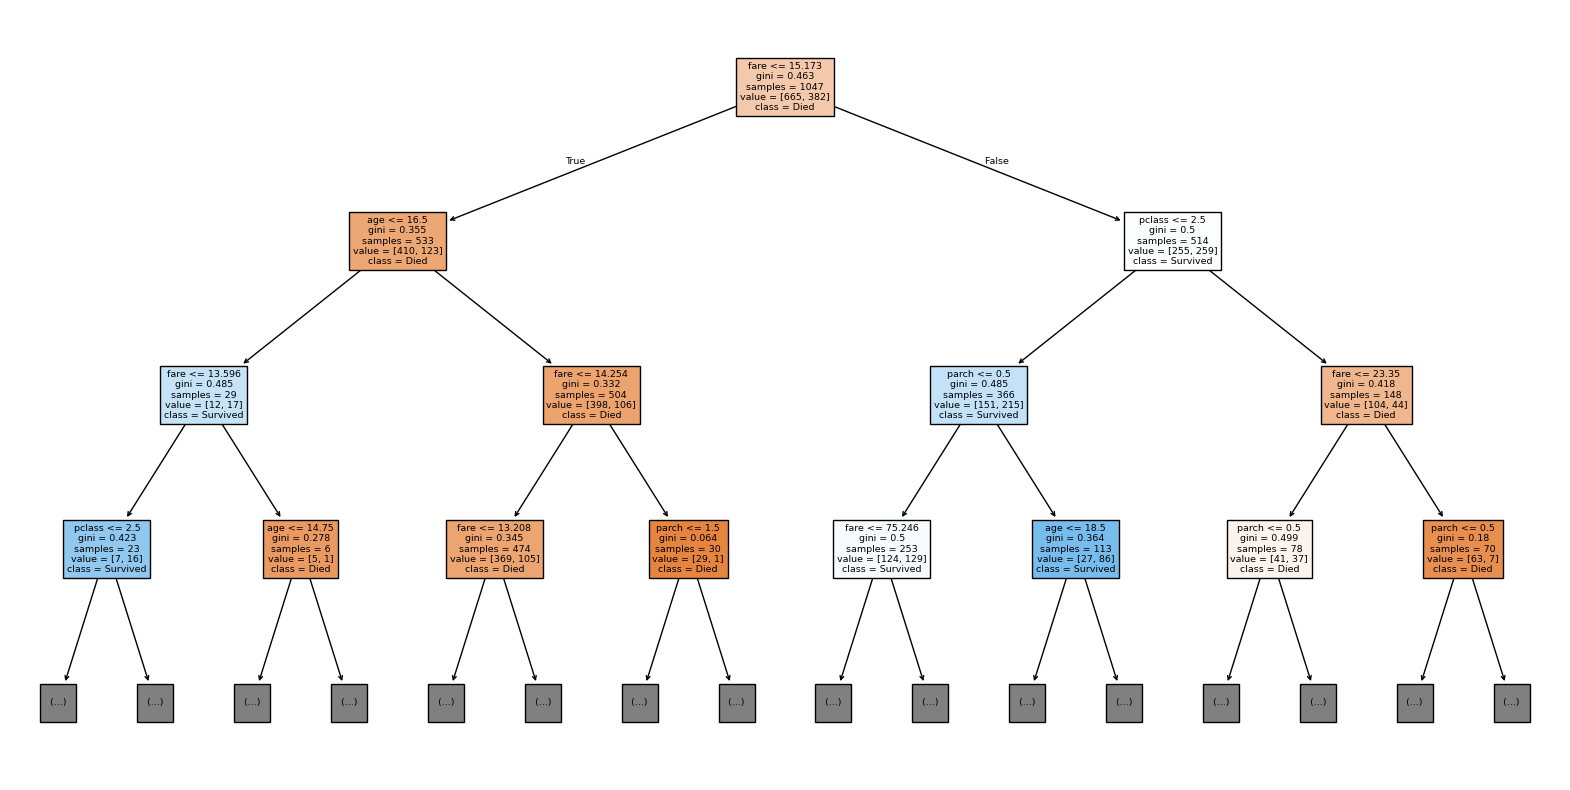

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3
)

plt.show()

In [5]:
root_feature_index = tree_model.tree_.feature[0]
root_feature_name = X.columns[root_feature_index]

print("Root split feature:", root_feature_name)

Root split feature: fare


The root split is the first question the tree asks. In Titanic models, this is often sex, because women had a much higher survival rate than men. This makes logical sense because the Titanic evacuation followed the idea of women and children first.

## #5 ##

In [7]:
short_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

short_tree.fit(X_train, y_train)

short_test_preds = short_tree.predict(X_test)

short_test_acc = accuracy_score(y_test, short_test_preds)

print("Original Deep Tree Test Accuracy:", test_acc)
print("Short Tree Test Accuracy:", short_test_acc)

Original Deep Tree Test Accuracy: 0.6755725190839694
Short Tree Test Accuracy: 0.6870229007633588


Limiting the tree depth often improves test performance because it prevents the model from becoming too specific to the training data. A shorter tree focuses on the strongest patterns instead of memorizing every small detail. This can reduce overfitting and help the model perform better on new data.

## #6 ##

In [10]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

forest_model.fit(X_train, y_train)

forest_preds = forest_model.predict(X_test)

forest_acc = accuracy_score(y_test, forest_preds)

print("Random Forest Test Accuracy:", forest_acc)

Random Forest Test Accuracy: 0.6679389312977099


A single Decision Tree makes predictions by following one set of yes or no splits. A Random Forest builds many different trees and then combines their predictions using a majority vote. This usually makes the model more reliable because it is not depending on just one tree.

## #7 ##

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, forest_preds)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

[[114  30]
 [ 57  61]]
True Negatives: 114
False Positives: 30
False Negatives: 57
True Positives: 61


False Positives are passengers the model predicted would survive but actually died. False Negatives are passengers the model predicted would die but actually survived.

## #8 ##

In [17]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

precision = precision_score(y_test, forest_preds)
recall = recall_score(y_test, forest_preds)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.6703296703296703
Recall: 0.5169491525423728


If I were a rescue coordinator and my goal was to “leave no one behind,” I would care more about maximizing recall. Recall measures how many actual survivors the model successfully found. In this situation, it would be worse to miss a real survivor than to accidentally include someone who was not a survivor.

## #9 ##

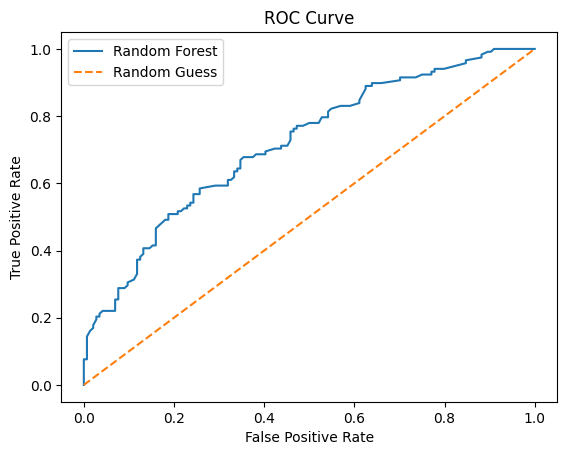

AUC Score: 0.7161899717514125


In [20]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

forest_probs = forest_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, forest_probs)

auc_score = roc_auc_score(y_test, forest_probs)

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

If the AUC is 0.85, the model is much better than a random coin flip. A coin flip would have an AUC of about 0.50, while 0.85 means the model is good at distinguishing between passengers who survived and passengers who died.

In [21]:
## 10

10

In [22]:
importances = forest_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

  Feature  Importance
4    fare    0.422210
1     age    0.381419
0  pclass    0.073655
2   sibsp    0.066979
3   parch    0.055736


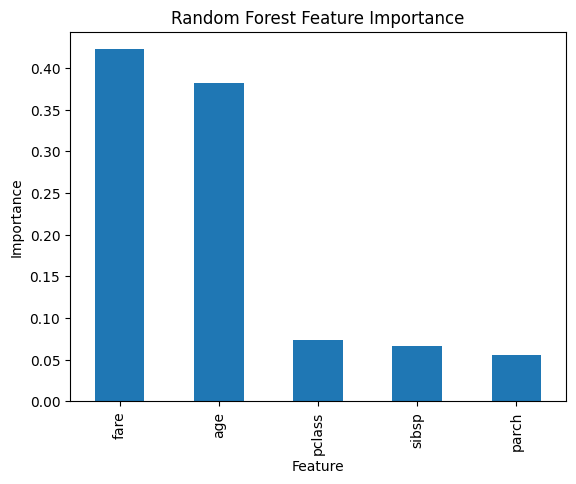

In [23]:
feature_importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

The three most influential features are the top three features in the feature importance table. In many Titanic models, these are often Sex, Fare, and Age or Pclass. If a feature has an importance close to 0, the model found it mostly useless for making predictions.